<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 1 — Introducción con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->
<font color="#7F000E" size=3> Nivel: Ingeniería Biomédica — 7.º ciclo / 4.º año </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Importación, exploración, visualización y exportación de ECG </font><br>
</div>

---

## Objetivos

Al finalizar este laboratorio, el estudiante será capaz de:

1. Acceder a una base de datos de señales fisiológicas de PhysioNet.
2. Cargar un registro ECG mediante la librería `wfdb`.
3. Identificar la frecuencia de muestreo, número de canales, nombres de canales y duración.
4. Construir el eje temporal de una señal discreta.
5. Visualizar una señal ECG mediante diferentes representaciones.
6. Analizar un segmento de la señal.
7. Exportar un segmento ECG a formato `.wav`.
8. Interpretar las diferencias entre una señal biomédica y una señal de audio.
9. Formular observaciones básicas sobre la morfología y amplitud de un ECG.

> **Importante:** el archivo WAV generado es una representación de la señal ECG en un formato reproducible por herramientas de audio. No significa que el ECG sea originalmente una señal acústica.



## 1. Introducción

Las señales biomédicas son señales generadas por procesos fisiológicos. Algunos ejemplos son:

- ECG — electrocardiograma
- EEG — electroencefalograma
- EMG — electromiograma
- EOG — electrooculograma
- PPG — fotopletismografía

En este laboratorio trabajaremos con una señal **ECG real** obtenida de **PhysioNet**.

PhysioNet proporciona acceso a numerosas bases de datos fisiológicas. Una de las bases más conocidas es la **MIT-BIH Arrhythmia Database**, que contiene registros electrocardiográficos anotados.

### Concepto fundamental: DATABASE + RECORD

Un registro no debe identificarse solamente por su número.

Por ejemplo:

```python
DATABASE = "mitdb"
RECORD = "100"
```

significa que estamos solicitando el registro `100` de la base de datos `mitdb`.

El mismo número de registro puede tener un significado diferente si pertenece a otra base de datos. Por ello, siempre debemos interpretar:

```text
BASE DE DATOS + RECORD
```

como la identificación del registro.



## 2. Parámetros configurables

En esta sección el estudiante podrá cambiar los parámetros principales del laboratorio.

### Parámetros

| Parámetro | Descripción | Ejemplo |
|---|---|---|
| `DATABASE` | Base de datos de PhysioNet | `"mitdb"` |
| `RECORD` | Identificador del registro | `"100"` |
| `CHANNEL` | Canal que se desea analizar | `0` |
| `DURATION` | Duración del segmento en segundos | `10` |
| `OUTPUT_WAV` | Nombre del archivo WAV | `"ecg_100.wav"` |

### Pregunta inicial

Antes de ejecutar el código, responda:

**¿Qué cree que representa `CHANNEL = 0`?**

Anote su hipótesis y compruébela después de ejecutar el notebook.

**- Mi hipótesis es que CHANNEL= 0 indica o hace referencia al primer canal disponible del registro ECG. Puesto que en Python, las posiciones se contabilizan desde el número cero.**



In [ ]:

# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "100"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")


Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_100_channel_0.wav



## 3. Instalación de librerías

Utilizaremos:

- **WFDB:** acceso a registros de PhysioNet.
- **NumPy:** procesamiento numérico.
- **Pandas:** organización de datos.
- **Matplotlib:** visualización.
- **SciPy:** exportación de la señal a WAV.


In [ ]:
!pip install uv

In [ ]:

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib


In [ ]:

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")


Librerías importadas correctamente.



## 4. Cargar el registro desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

Usaremos:

```python
record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)
```

El argumento `pn_dir` indica que el registro se obtendrá desde una base de datos disponible en PhysioNet.


In [ ]:

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")


Registro cargado correctamente.



## 5. Explorar la información del registro

Antes de procesar una señal biomédica es necesario conocer sus características.

Algunos parámetros importantes son:

- `fs`: frecuencia de muestreo.
- `sig_len`: número de muestras.
- `n_sig`: número de canales.
- `sig_name`: nombres de los canales.
- `units`: unidades de las señales.


In [ ]:

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)


INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos



### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo del registro?
**- La frecuencia de muestreo fs es 360 Hz.**
2. ¿Cuántos canales tiene?
**- Cuenta con 2 canales.**
3. ¿Cómo se llama el canal seleccionado?
**- De acuerdo con el parámetro definido en un inicio, el cual fue CHANNEL= 0, el canal seleccionado vendría a ser el de la posición 0 de la lista "Canales", impreso en la pregunta 5. Por ende, el canal seleccionado sería "MLII"**
4. ¿Cuál es la duración total del registro?
**- La duración total del registro es de 1805.56 segundos.**
5. Si `fs = 360 Hz`, ¿cuántas muestras se adquieren en 1 segundo?
**- Para calcular la cantidad de muestras adquiridas, haremos uso de la fórmula: N=fs*t, y haciendo el cálculo respectivo N=360x10= 360, por ende, se adquieren 360 muestras en un segundo.**
6. ¿Cuántas muestras corresponden a un segmento de 10 segundos?
**- Usando fs=360Hz, y la misma fórmula que la usada en el inciso anterior, N=360*10= 3600, por ende, se adquieren 3600 muestras en 10 segundos.**



## 6. Identificación del canal

El parámetro:

```python
record.sig_name
```

permite conocer qué señal corresponde a cada canal.

Por ejemplo, conceptualmente:

```text
CHANNEL 0 → primer canal
CHANNEL 1 → segundo canal
...
```

No debemos asumir que todos los registros tienen los mismos canales. Siempre debemos consultar los metadatos del registro.


In [ ]:

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")


Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V5 [mV]

Canal seleccionado: 0
Nombre            : MLII



## 7. Extraer la señal ECG

Las muestras de la señal se encuentran en:

```python
record.p_signal
```

Esta estructura contiene:

```text
filas    → muestras
columnas → canales
```

Por tanto:

```python
signal = record.p_signal[:, CHANNEL]
```

selecciona todas las muestras del canal indicado.


In [ ]:

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])


Número de muestras: 650000
Canal: MLII
Unidad: mV

Primeras 10 muestras:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]



## 8. Crear el eje temporal

Una señal digital está formada por muestras.

Si la frecuencia de muestreo es:

\[
f_s
\]

entonces el intervalo entre muestras es:

\[
T_s = \frac{1}{f_s}
\]

y el instante asociado a la muestra `n` es:

\[
t[n] = \frac{n}{f_s}
\]

Esta relación es fundamental para interpretar correctamente una señal biomédica.


In [ ]:

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")


Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos



# 9. GRÁFICA 1 — Señal ECG completa

En esta primera visualización observaremos todo el registro.

### Objetivo

Reconocer:

- eje temporal;
- amplitud;
- duración;
- comportamiento general de la señal;
- posibles cambios de morfología.


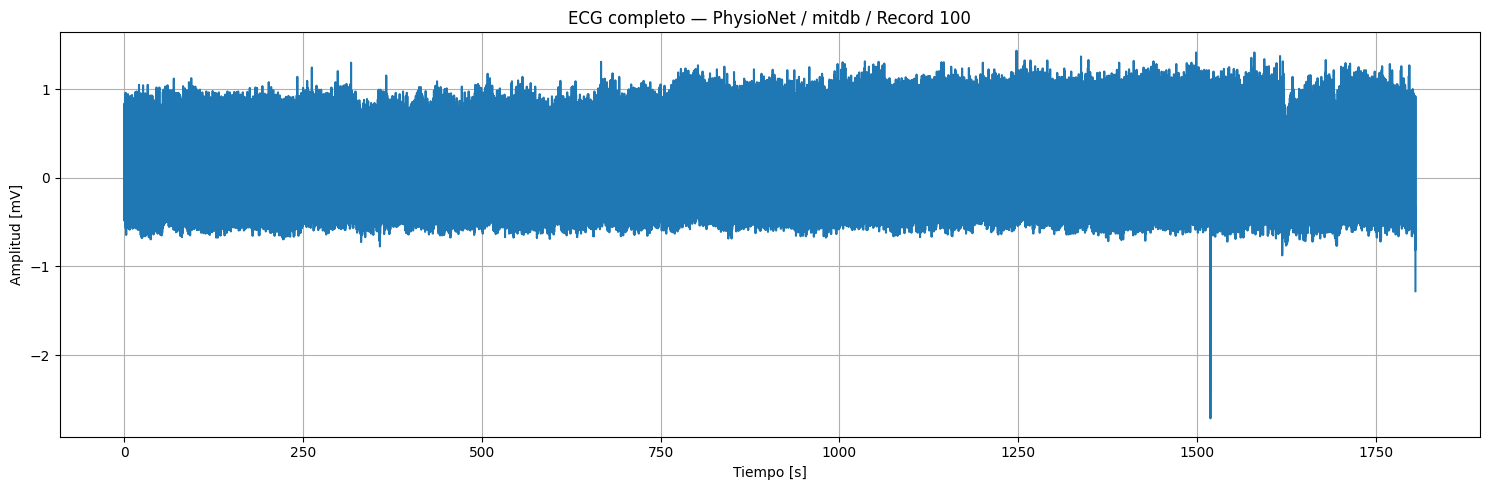

In [ ]:

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 2

1. ¿La señal presenta una amplitud constante?
**- No, la amplitud va cambiando durante todo el registro, tomando valores desde -0.8mV a 1.4mV, aproximadamente. Además, cerca de los 1500 segundos, se observa una caída brusca, llegando aproximadamente a los -2.8mV.**
2. ¿Se pueden identificar visualmente complejos QRS?
**- No se pueden distinguir visualmente, ya que los complejos QRS aparecen muy juntos y forman una franja azul gruesa. Para poder visualizarlos, se necesitaría reducir el intervalo de tiempo mostrado y ampliar visualmente un segmento de pocos segundos.**
3. ¿La morfología permanece igual durante todo el registro?
**- No permanece igual. Se pueden observar cambios en en el grosor y en los límites de la señal. Por ejemplo, desde los 750 segundos, la amplitud de la señal parece empezar a aumentar, o cerca a los 1500 segundos, ocurre una caída muy brusca.**
4. ¿Se observa ruido?
**-Sí se observan algunas variaciones bruscas, especialmente la caída de la señal cerca a los 1500 segundos, aproximadamente a los -2.8mV. También se observa una caída brusca al final del registro, alrededor de los 1850 segundos aproximadamente.**
5. ¿Qué ventajas tiene visualizar una señal durante varios minutos?
**- Permite observar el comportamiento general de la señal, y poder así localizar las zonas donde ocurran cambios bruscos, y poder filtrarlas, y quedarnos únicamente con la señal que nos interesa analizar.**
6. ¿Qué limitaciones tiene una gráfica demasiado extensa?
**- En este caso, la gráfica está mostrando aproximadamente 30 minutos en una sola imagen, lo que genera que los latidos se vean muy comprimidos. Por ello, no se pueden distinguir individualmente los complejos QRS ni analizar con claridad cómo se comporta cada latido.**



# 10. GRÁFICA 2 — Segmento ECG ampliado

Una señal completa puede dificultar el análisis de eventos individuales.

Por ello seleccionaremos solamente los primeros `DURATION` segundos.


In [ ]:

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")


Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


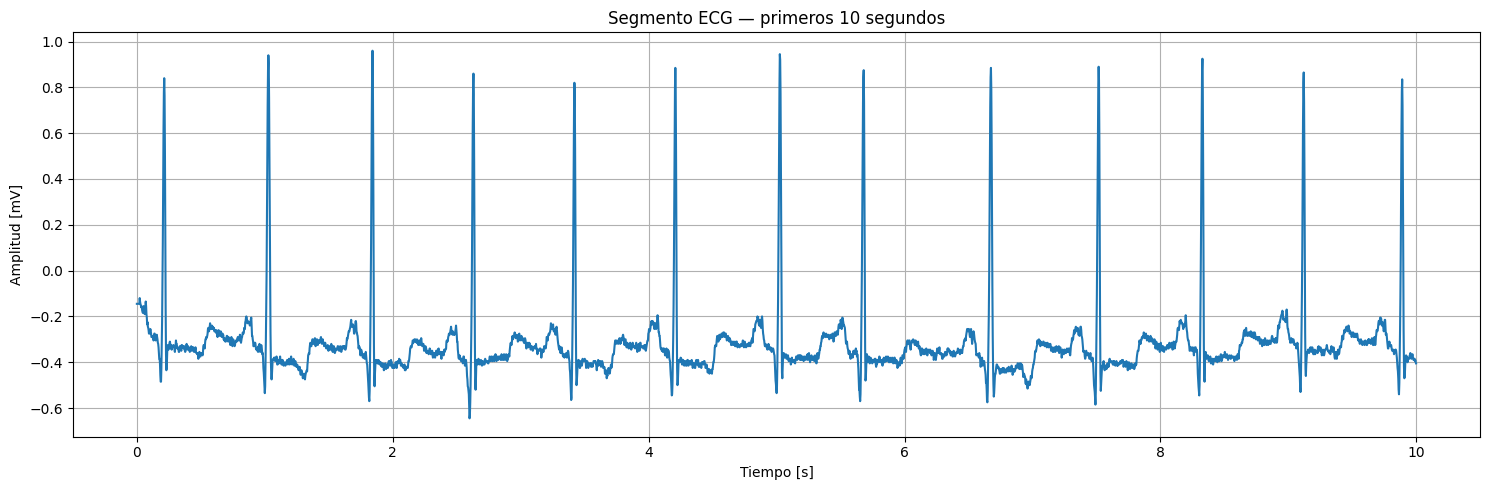

In [ ]:

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Actividad

Observe cuidadosamente la gráfica.

Intente identificar:

- onda P;
- complejo QRS;  **estos son los picos más altos, estrechos y repetitivos.**
- onda T;
- intervalo entre complejos QRS; **tiempo entre un pico alto y el siguiente.**
- posibles artefactos.

> **Nota:** la identificación automática de ondas no forma parte de este laboratorio. Aquí el objetivo es desarrollar una primera capacidad de observación de señales biomédicas.



# 11. GRÁFICA 3 — Histograma de amplitudes

El histograma permite observar cómo se distribuyen los valores de amplitud de la señal.

Podemos utilizarlo para introducir conceptos como:

- media;
- dispersión;
- valores extremos;
- distribución de amplitudes.


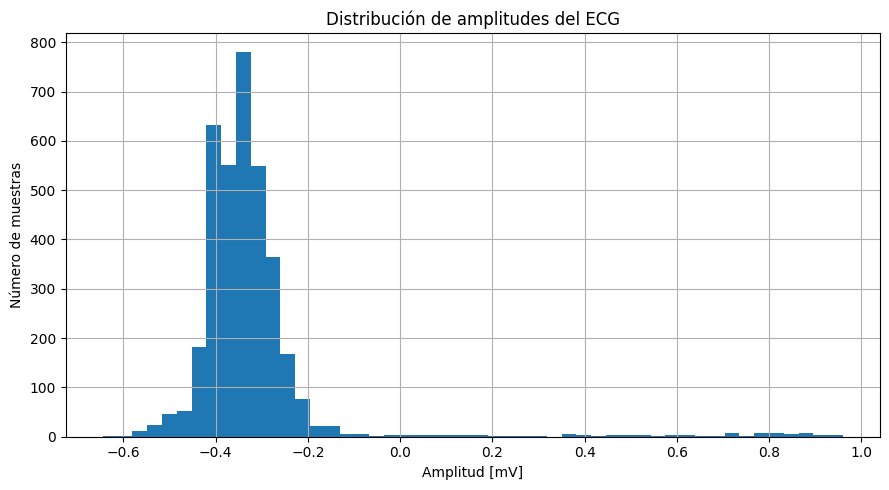

In [ ]:

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 3

1. ¿Dónde se concentra la mayor cantidad de muestras?
**- La mayor cantidad de muestras se concentra aproximadamente entre -0.43 mV y -0.25 mV. La barra más alta se encuentra cerca de -0.35 mV y contiene alrededor de 780 muestras.**
2. ¿La distribución parece simétrica?
**- La distribución no parece simétrica, puesto que la mayor parte de los datos está concentrada entre -0.43mV y -0.30 mV, y desde -0.1mV, aproximadamente, hacia la derecha se observa una cola larga con un número de muestras cercana a 0, llegando hasta 0.95mV.**
3. ¿Existen valores extremos?
**- Sí existen valores extremos. En el lado negativo existen valores negativos cercanos -0.65mV, y en el lado positivo valores cercanos a 0.95mV.**
4. ¿Qué podría producir valores de amplitud muy diferentes al valor central?
**- Los valores de amplitud muy diferentes al de valor central podrían indicar ruido, movimiento del paciente o interferencias obtenidas en el registro del paciente.**
5. ¿El histograma conserva información temporal? Explique.
**- No conserva información temporal. El histograma muestra cuántas muestras existen por cada intervalo de amplitud. Por ejemplo, permite saber que cerca de -0.35mV existen aproximadamente 780 muestras, aunque no indica en qué segundo del ECG se obtuvo.**



# 12. GRÁFICA 4 — Representación discreta

Una señal digital no solamente puede representarse como una línea continua visualmente.

También podemos observar sus muestras individuales.

Esto permite introducir el concepto:

\[
x[n]
\]

donde `n` representa el índice de muestra.


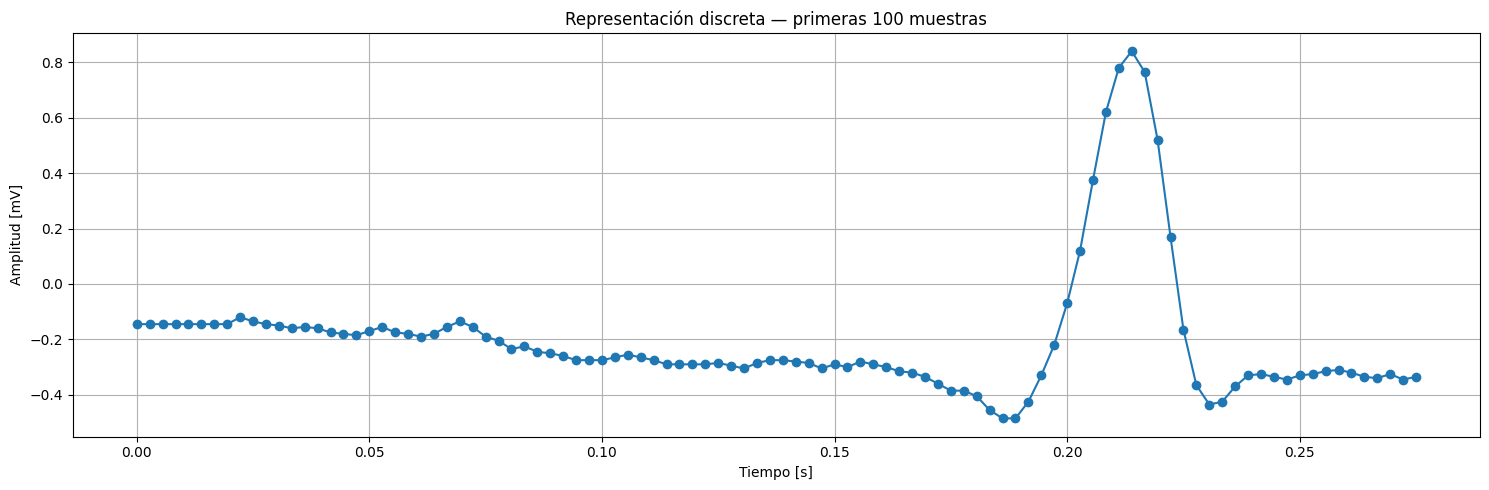

In [ ]:

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 4

1. ¿Cuántas muestras existen por segundo?
**- Existen 360 muestras por segundo, ya que la frecuencia de muestreo del ECG es fs = 360 Hz. En la gráfica se muestran solamente las primeras 100 muestras, y como n= [0,....,99], correspondería a t= 99/360= 0.275 segundos de la señal.**
2. ¿Qué ocurre si aumentamos `fs`?
**- Si aumentamos fs, se registran más muestras por segundo. Por lo tanto, los puntos estarían más juntos y se podría representar con mayor detalle la forma real de la señal ECG, especialmente el pico que llega aproximadamente a 0.83 mV cerca de los 0.23 segundos. Sin embargo, también aumentaría la cantidad de datos almacenados, es decir, requerería mayor procesamiento.**
3. ¿Qué ocurre si disminuimos `fs`?
**- Si disminuimos fs, se registran menos muestras por segundo y los puntos estarían más separados. Esto podría ocasionar que se pierdan detalles importantes, como la forma del pico que se observa entre 0.20 y 0.24 segundos. Además, si el número de muestras disminuye demasiado, la señal se podría ver muy distorsinada y el parecido a la señal sería menor.**
4. ¿Qué representa el eje `n` en una señal discreta?
**- El eje n representa el número de muestras. En esta gráfica se presentan 100 muestras, por lo que los índices van desde n = 0 hasta n = 99. Aunque la gráfica en el eje x muestre tiempo en segundos, cada punto corresponde a un valor específico de n.**
5. ¿Cuál es la relación entre `n`, `fs` y `t`?
**- t[n] = n/fs, lo cual significa que el tiempo de cada muestra se obtiene dividiendo el índice de la muestra "n" entre la frecuencia de muestreo fs. Por ejemplo, para la muestra n=99, t[99]= 99/360 = 0.275 segundos. Por ello, las primeras 100 muestras abarcan desde 0 hasta aproximadamente 0.275 segundos**



# 13. Estadística básica de la señal

Antes de exportar la señal calcularemos algunos parámetros básicos.


In [ ]:

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")


ESTADÍSTICAS DEL SEGMENTO
Media             : -0.3199
Desviación estándar: 0.1702
Mínimo            : -0.6450
Máximo            : 0.9600
Rango             : 1.6050



# 14. Convertir ECG a archivo WAV

El formato WAV es común en aplicaciones de audio. Sin embargo, nuestra señal es un ECG.

Para poder almacenarla como WAV realizaremos:

```text
ECG original
     ↓
Eliminar componente media
     ↓
Normalizar amplitud
     ↓
Convertir a int16
     ↓
Guardar WAV
```

### ¿Por qué normalizar?

Los valores del ECG están expresados en unidades fisiológicas, mientras que el WAV suele utilizar representaciones enteras, como `int16`.

Utilizaremos el rango:

\[
-32768 \leq x \leq 32767
\]

para `int16`.


In [ ]:

# ============================================
# PREPARAR ECG PARA WAV
# ============================================

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")


Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -8322
Máximo int16    : 32767



# 15. Guardar el archivo WAV

La frecuencia de muestreo del WAV será la misma frecuencia de muestreo del registro ECG.

Esto es importante porque permite conservar la separación temporal entre las muestras.


In [ ]:

# ============================================
# GUARDAR WAV
# ============================================

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV)


Archivo WAV generado correctamente:
ecg_record_100_channel_0.wav



# 16. Reproducir el archivo WAV

En Google Colab/Jupyter podemos utilizar un reproductor integrado.


In [ ]:

# Reproducir el archivo WAV

display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
    )
)



### Preguntas de análisis 5

1. ¿Puede escuchar claramente la señal?
**- Inicialmente no pude reproducir la señal porque el archivo WAV tenía una frecuencia de muestreo de 360 Hz, la cual no era compatible con el reproductor. Después de adaptarla a 8000 Hz, sí pude reproducirla, aunque no se escucha como un sonido claro, sino más como pulsos o pequeñas variaciones, pero muy bajas.**
2. ¿El sonido corresponde a un sonido fisiológico real?
**- No, el sonido reproducido no corresponde al sonido real del corazón. Es una representación en audio de las muestras eléctricas del ECG. Además, el cambio a 8000 Hz se realizó solamente para que el reproductor pudiera leer el archivo.**
3. ¿Por qué un ECG puede convertirse a WAV?
**- Porque tanto un ECG digital como un archivo WAV están formados por muestras ordenadas en el tiempo. Por eso, los valores del ECG pueden normalizarse y convertirse al formato `int16` utilizado por los archivos WAV.**
4. ¿Qué información se conserva al hacer la conversión?
**- Se conserva el orden de las muestras, la forma relativa de la señal y su duración aproximada, ya que el cambio a 8000 Hz se realizó mediante remuestreo. Sin embargo, los valores ya no representan directamente la amplitud original en milivoltios.**
5. ¿Qué información fisiológica podría perderse al escucharla?
**- Al escucharla se pierde la referencia visual y resulta difícil reconocer las ondas P y T o los complejos QRS. También se pierde la escala original en milivoltios debido a la normalización de la señal.**
6. ¿Qué diferencia existe entre representar un ECG gráficamente y reproducirlo como audio?
**- En la gráfica se puede observar la amplitud en función del tiempo y reconocer la forma de los latidos. En el audio solamente se escuchan las variaciones de la señal, pero no se pueden distinguir fácilmente los valores de amplitud ni las partes específicas del ECG.**



# 17. Descargar el archivo WAV

En Google Colab se puede descargar el archivo generado.


In [ ]:

# ============================================
# DESCARGAR WAV EN GOOGLE COLAB
# ============================================

try:
    from google.colab import files
    files.download(OUTPUT_WAV)
except ImportError:
    print("Este entorno no es Google Colab.")
    print(f"El archivo está disponible localmente como: {OUTPUT_WAV}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 18. Ejercicios propuestos

## Ejercicio 1 — Cambiar de registro

Modifique:

```python
RECORD = "100"
```

por otro registro válido de la misma base de datos.

Compare:

- frecuencia de muestreo;
- número de canales;
- nombres de canales;
- morfología;
- amplitud;
- distribución.

### Entregable

Incluya una captura o las cuatro gráficas del nuevo registro y escriba una comparación con el registro original.


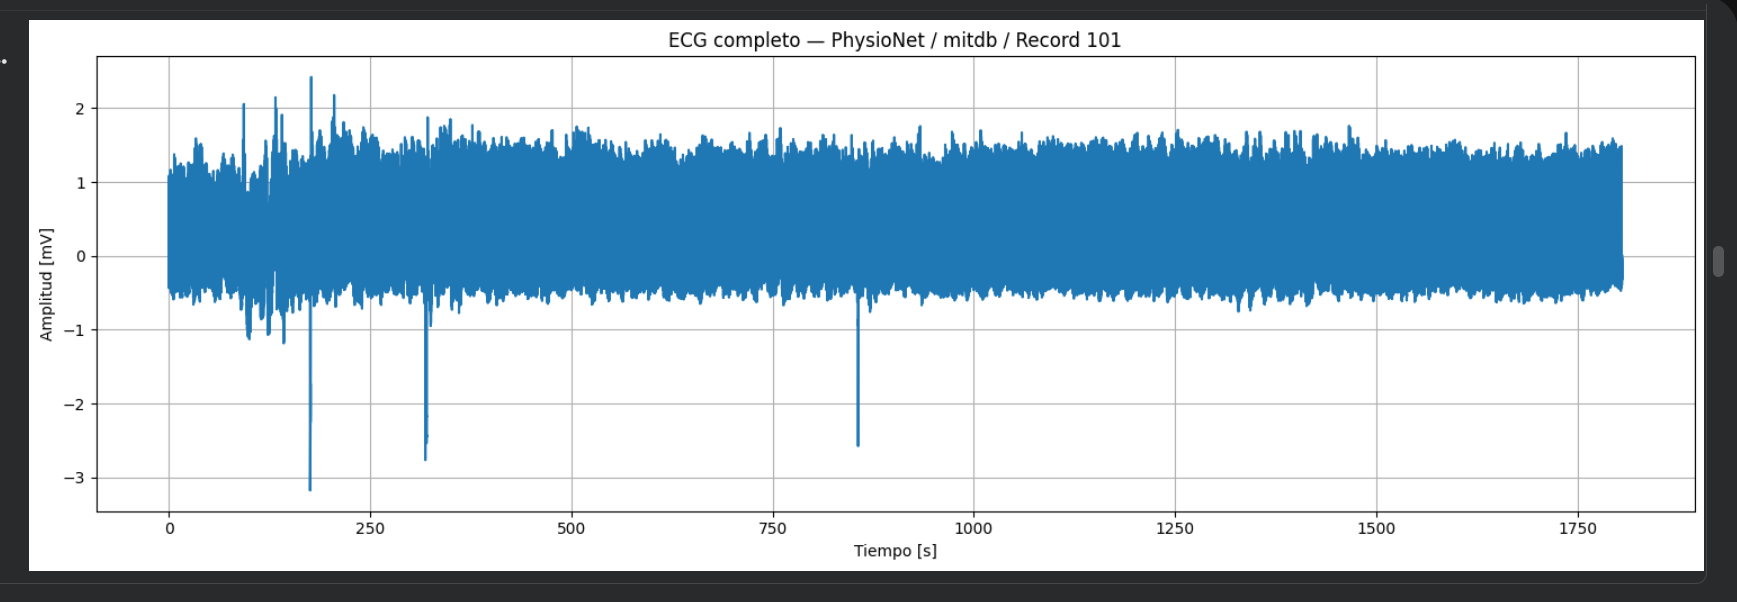

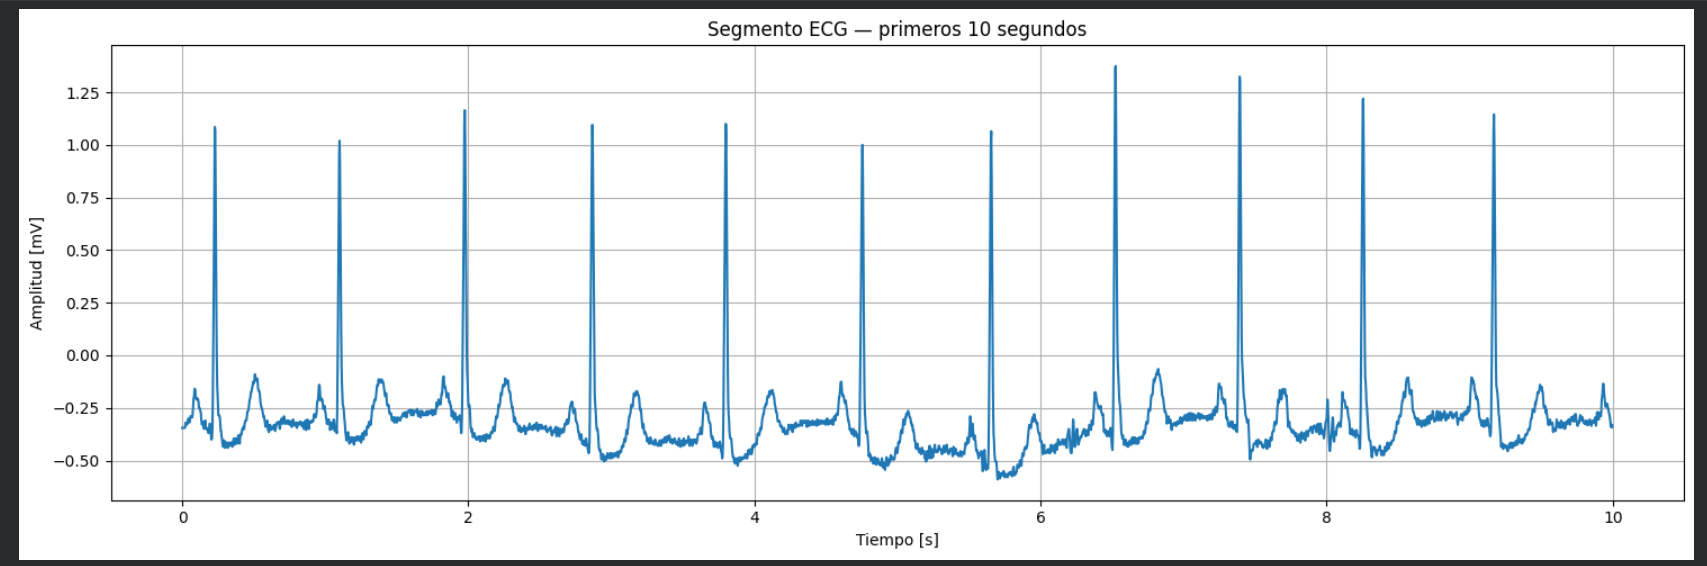

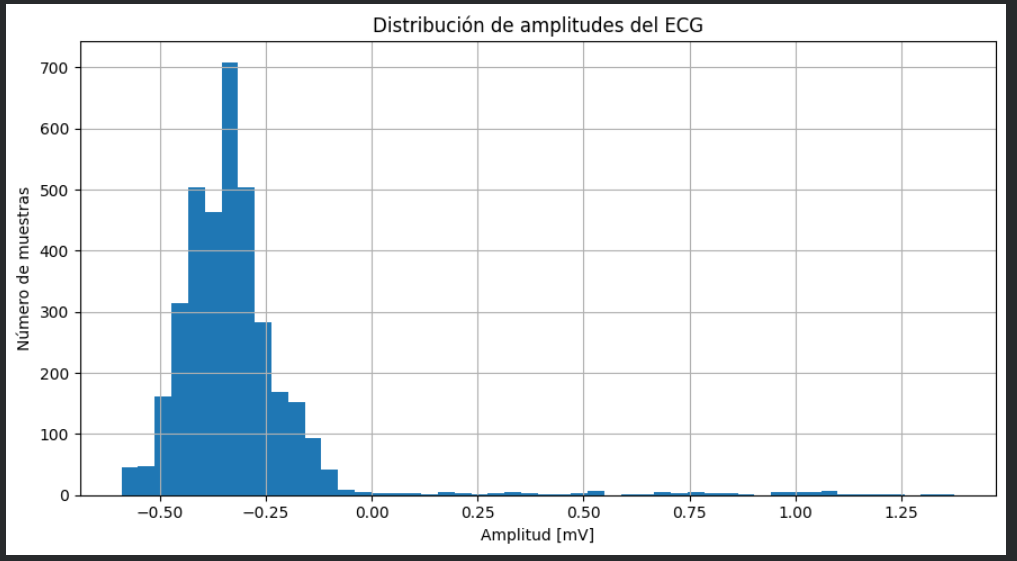


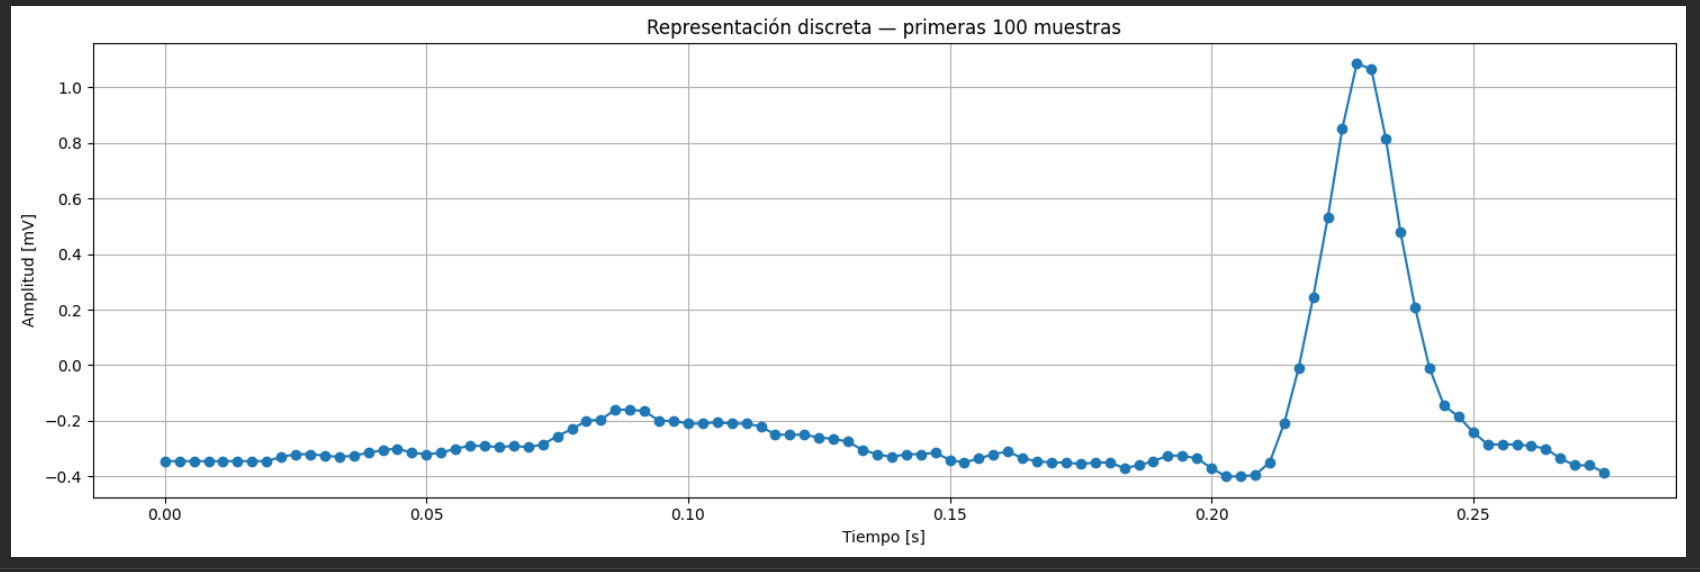

### Comparación entre el registro 100 y el registro 101

1. **Frecuencia de muestreo:**

- Ambos registros tienen la misma frecuencia de muestreo, la cual es de 360 Hz. Por ende, en ambos casos se obtienen 360 muestras por segundo y 3600 muestras durante los 10 segundos analizados.

2. **Número y nombres de canales:**

- Ambos registros cuentan con 2 canales. El registro 100 presenta los canales MLII y V5, mientras que el registro 101 presenta los canales MLII y V1. Para realizar las gráficas se seleccionó CHANNEL = 0, que corresponde al canal MLII en ambos registros.

3. **Morfología:**

- La morfología de los registros es parecida, ya que en ambos se observan complejos QRS altos, estrechos y repetitivos. Sin embargo, en los primeros 10 segundos del registro 101, los picos presentan una mayor amplitud y la línea base varía un poco más. Por otro lado, en el registro 100, los picos presentan una menor variación en su altura.

4. **Amplitud:**

- En los primeros 10 segundos del registro 100, la amplitud varía aproximadamente desde -0.65 mV hasta 0.96 mV. En cambio, en el registro 101 varía aproximadamente desde -0.60 mV hasta 1.40 mV. Por ello, el registro 101 presenta una mayor amplitud positiva que el registro 100.

- En la gráfica completa del registro 100, la mayor parte de la señal varía aproximadamente entre -0.8 mV y 1.4 mV, aunque cerca de los 1500 segundos ocurre una caída brusca hasta aproximadamente -2.8 mV. En el registro 101 se observan picos positivos que llegan aproximadamente hasta 2.5 mV y varias caídas bruscas, siendo la mayor cercana a -3.2 mV alrededor de los 175 segundos.

5. **Distribución de amplitudes**

- En ambos registros, la mayor cantidad de muestras se encuentra alrededor de valores negativos. En el registro 100, las muestras se concentran principalmente entre -0.43 mV y -0.25 mV, con una barra máxima de aproximadamente 780 muestras cerca de -0.35 mV. En el registro 101, la mayoría se concentra aproximadamente entre -0.50 mV y -0.20 mV, y la barra más alta contiene cerca de 710 muestras alrededor de -0.35 mV.

- Las dos distribuciones son asimétricas y presentan una cola hacia el lado positivo. En el registro 100, esta cola llega aproximadamente hasta 0.95 mV; mientras que en el registro 101 llega hasta aproximadamente 1.40 mV. Esto coincide con la mayor amplitud de los complejos QRS observada en el registro 101.

6. **Representación discreta**
- En las primeras 100 muestras del registro 100 se observa un pico que llega aproximadamente hasta 0.83 mV cerca de los 0.23 segundos. En el registro 101, el pico aparece también cerca de los 0.23 segundos, pero alcanza aproximadamente 1.10 mV. Por ello, en este intervalo, el registro 101 presenta un complejo QRS de mayor amplitud.

---

## Ejercicio 2 — Cambiar de canal

Modifique:

```python
CHANNEL = 0
```

por otro canal disponible.
Responda:

1. **¿Qué nombre tiene el nuevo canal?**

- Al cambiar el parámetro de CHANNEL = 0 a CHANNEL = 1, el nuevo canal seleccionado es V5.

2. **¿Tiene las mismas unidades?**

- Sí, el canal V5 también tiene como unidad los milivoltios (mV), al igual que el canal MLII.

3. **¿La morfología es igual?**

- No es exactamente igual. Aunque los dos canales registran la actividad eléctrica del mismo corazón durante el mismo tiempo, la forma y la amplitud de las ondas cambian. En el canal V5, los picos positivos de los complejos QRS son más pequeños y se observan ondas negativas más marcadas después de algunos picos.

4. **¿Qué diferencias observa?**

- En el canal MLII, los picos positivos de los primeros 10 segundos llegan aproximadamente hasta 0.96 mV y el valor mínimo es de -0.645 mV. En cambio, en el canal V5, el máximo llega hasta 0.80 mV y el mínimo hasta -0.47 mV. Por ello, el canal MLII presenta un rango de amplitud mayor que el canal V5.

- La media del canal MLII es de -0.3199 mV, mientras que la del canal V5 es de -0.2032 mV. También se observa que la desviación estándar disminuye de 0.1702 mV en MLII a 0.1225 mV en V5, lo cual indica que las amplitudes del canal V5 presentan una menor variación respecto a su media.

- Finalmente, el rango del canal MLII es de 1.6050 mV, mientras que el rango de V5 es de 1.2700 mV. Estas diferencias se producen porque MLII y V5 observan la actividad eléctrica del corazón desde derivaciones distintas.
---

## Ejercicio 3 — Cambiar la duración

Pruebe:

```python
DURATION = 5
```

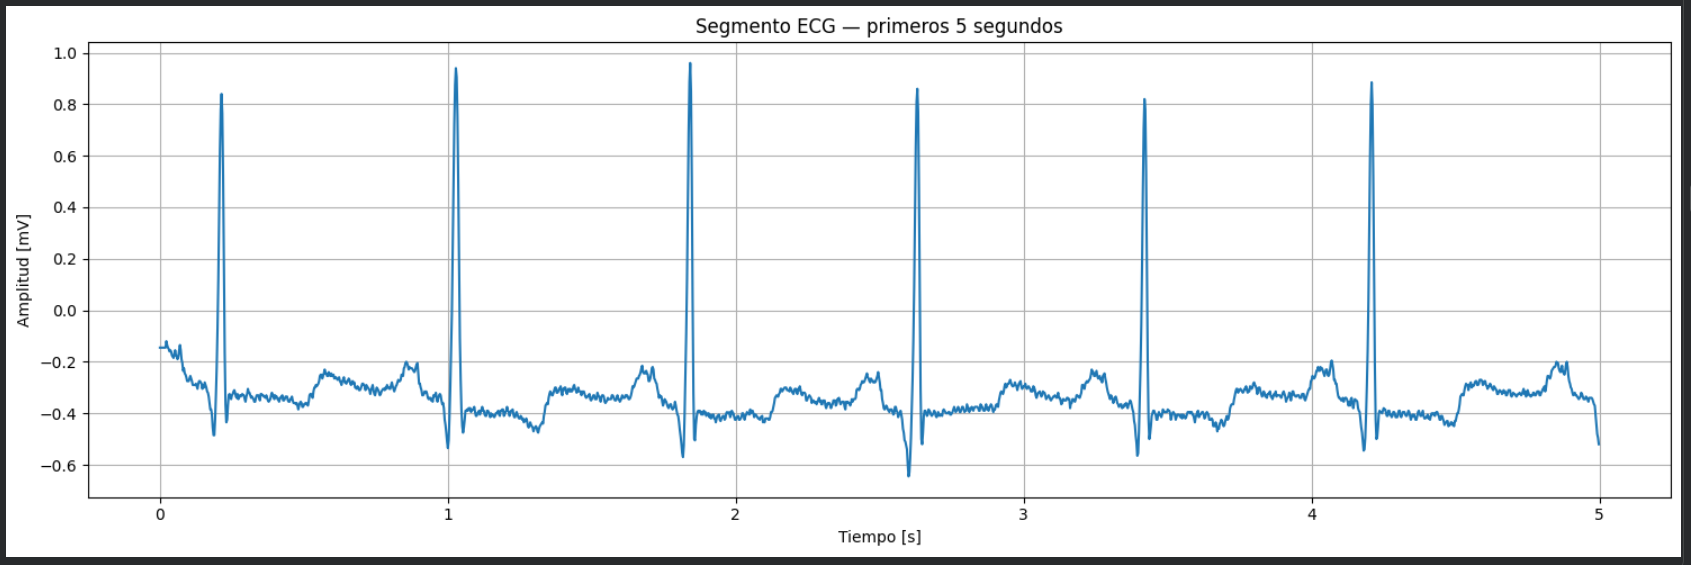

```python
DURATION = 20
```

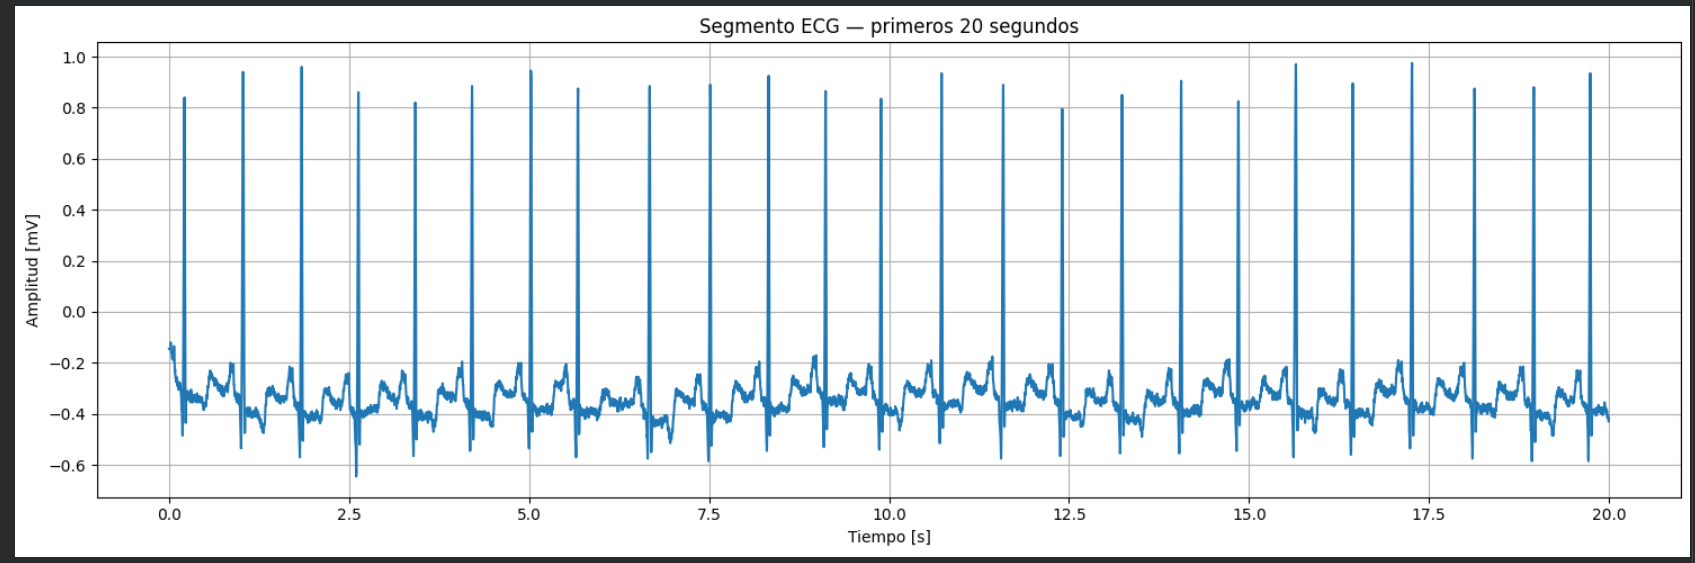


y compare las visualizaciones.

Explique por qué una duración demasiado pequeña o demasiado grande puede dificultar el análisis.


### **Comparación de las visualizaciones**

- Para una duración de **5 segundos** se analizaron: N = fs x t

Reemplazando:
N= 360 x 5 = 1800

Por lo tanto, se analizaron 1800 muestras. En la gráfica se observan aproximadamente 6 complejos QRS, cuyos picos llegan hasta valores cercanos a 0.96 mV. Como el intervalo mostrado es pequeño, los latidos aparecen más separados y se puede observar con mayor claridad la forma de cada complejo.

- Para una duración de **20 segundos** se analizaron: N = 360 x 20 = 7200

Por lo tanto, se analizaron 7200 muestras. En esta gráfica se observan aproximadamente 25 complejos QRS, con amplitudes máximas cercanas a 0.97 mV. Al mostrar una mayor duración, se pueden observar más latidos y analizar mejor si el ritmo se mantiene regular. Sin embargo, los complejos aparecen más juntos y resulta más difícil analizar detalladamente la forma de cada uno.

- Entonces:

Una duración demasiado pequeña puede dificultar el análisis porque contiene pocos latidos y podría no mostrar algún cambio o evento que pueda aparecer despúes. Por otro lado, una duración demasiado grande comprime la señal y hace más difícil distinguir las ondas y la morfología de cada complejo QRS.

En conclusión, la gráfica de 5 segundos es más útil para observar detalladamente la forma de los latidos, mientras que la gráfica de 20 segundos permite analizar mejor el comportamiento general y la regularidad de la señal.


## Ejercicio 4 — Frecuencia de muestreo

Suponga que:
\[
f_s = 360\ Hz
\]

### a) **Calcule el periodo de muestreo:**

\[
T_s = \frac{1}{f_s} = 1/360 = 0.00278 segundos
\]

### b) **¿Cuántas muestras existen en 5 segundos?**

- N= fs x t
- N= 360 x 5 = 1800 muestras
### c) **¿Cuántas muestras existen en 10 segundos?**

N= 360 x 10 = 3600 muestras

### d) **Explique qué sucedería si la frecuencia de muestreo fuese reducida significativamente.**

Si la frecuencia de muestreo se reduce bastante, se tomarían menos muestras por segundo y la señal perdería detalles. Por ejemplo, los picos del complejo QRS podrían verse menos definidos o incluso no registrarse correctamente. Además, la gráfica se vería menos precisa y podría dificultar el análisis del ECG.

---

## Ejercicio 5 — Análisis de amplitud

Utilizando el segmento seleccionado: Para este ejercicio se analizaron los primeros 10 segundos del registro 100, utilizando el canal 1, llamado V5. Los resultados obtenidos fueron los siguientes:


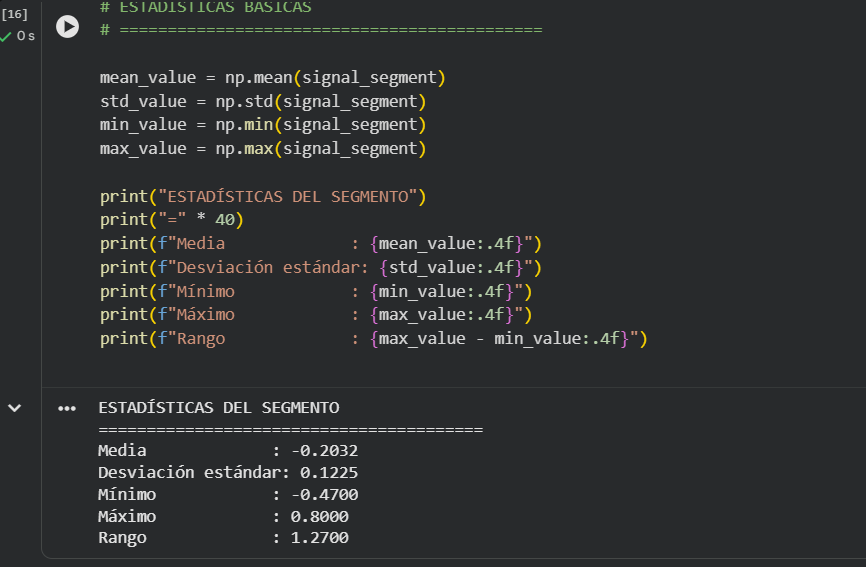

Explique qué información proporciona cada parámetro.


1. **Calcule la media.**

Media: -0.2032 mV

La media representa el valor promedio de todas las amplitudes del segmento. En este caso es negativa, por lo que la señal se mantiene principalmente por debajo de 0 mV.

2. **Calcule la desviación estándar.**

Desviación estándar: 0.1225 mV

La desviación estándar indica cuánto varían las amplitudes con respecto a la media. El valor obtenido muestra que la mayoría de las muestras no se alejan demasiado del valor promedio, aunque sí aparecen algunos picos del ECG.

3. **Determine el máximo.**

Máximo: 0.8000 mV

El máximo es la amplitud positiva más alta encontrada durante los 10 segundos analizados. Este valor probablemente corresponde a uno de los picos del complejo QRS.


4. **Determine el mínimo.**

Mínimo: -0.4700 mV

El mínimo representa la amplitud más baja del segmento. En este caso, la señal llegó hasta aproximadamente -0.47 mV.


5. **Calcule el rango.**

El rango representa la diferencia entre el valor máximo y el mínimo:
Rango = 0.8000-(-0.4700)=1.2700 mV



# 19. Preguntas conceptuales

Responda con sus propias palabras.

### 1. **¿Qué es PhysioNet?**

PhysioNet es una plataforma que contiene registros reales de señales biomédicas, como electrocardiogramas. En este laboratorio se utilizó para descargar y analizar señales de la base de datos MIT-BIH.

### 2. **¿Qué diferencia existe entre `DATABASE` y `RECORD`?**

'DATABASE' indica la base de datos que se está utilizando, que en este caso fue mitdb. En cambio, 'RECORD' indica el registro específico que se quiere analizar dentro de esa base de datos, por ejemplo, el registro 100 o 101.

### 3. **¿Qué representa `fs`?**

'fs' representa la frecuencia de muestreo de la señal. En este caso fue de 360 Hz, lo cual significa que el ECG contiene 360 muestras por cada segundo.

### 4. **¿Qué representa `CHANNEL`?**

'CHANNEL' indica cuál de los canales disponibles del ECG se está seleccionando para analizar. Por ejemplo, en el registro 100 se utilizó 'CHANNEL=1', que corresponde al canal V5.

### 5. **¿Qué representa `record.p_signal`?**

'record.p_signal' contiene los valores de amplitud de la señal que se descargó. Estos valores están expresados en unidades físicas, que en este caso son milivoltios. Además, contiene la información de todos los canales disponibles.

### 6. **¿Por qué necesitamos construir un eje temporal?**

Se necesita construir un eje temporal para saber en qué segundo ocurre cada muestra del ECG. Sin este eje solo tendríamos los valores de amplitud y su posición, pero no sabríamos exactamente a qué tiempo corresponden.

### 7. **¿Qué diferencia existe entre una señal continua y una señal discreta?**

Una señal continua tiene valores en cualquier instante de tiempo. En cambio, una señal discreta está formada por muestras tomadas en momentos separados. En este ECG se tomaron 360 muestras por segundo, por lo que la separación entre muestras fue de aproximadamente 1/360= 0.00278 segundos= 2.78 milisegundos.


### 8. **¿Por qué no debemos interpretar directamente un archivo WAV como si fuera una señal ECG?**

Porque el archivo WAV permite escuchar los valores del ECG como audio, pero el sonido obtenido no representa directamente los sonidos reales del corazón. Para analizar correctamente el ECG se debe observar su gráfica, sus amplitudes y su comportamiento en el tiempo.


### 9. **¿Qué ventajas ofrece trabajar con señales biomédicas reales en lugar de señales sintéticas?**

Las señales reales permiten observar variaciones, ruido, y cambios que normalmente se presentan durante una medición. Las señales sintéticas suelen ser más ordenadas y no siempre representan todas las dificultades que pueden aparecer en un registro real.

### 10. **¿Qué dificultades encontró durante el laboratorio**

Una dificultad fue entender cómo seleccionar el registro y el canal correcto, ya que al cambiar estos parámetros también cambiaban las gráficas y los resultados. Además, al mostrar todo el ECG, los complejos QRS se veían muy juntos y era necesario seleccionar solo algunos segundos para observarlos mejor. También tuve problemas para reproducir el archivo WAV, porque al inicio aparecía con una duración de 0:00, pero se pudo reproducir después de modificar la frecuencia utilizada para el audio.



# 20. Reto final

Seleccione un registro diferente y realice el siguiente análisis:

```text
PhysioNet
   ↓
Seleccionar RECORD
   ↓
Identificar canales
   ↓
Seleccionar canal ECG
   ↓
Analizar 10 segundos
   ↓
Gráfica ECG
   ↓
Histograma
   ↓
Representación discreta
   ↓
Estadística
   ↓
Exportar WAV
```

### Informe

Presente:

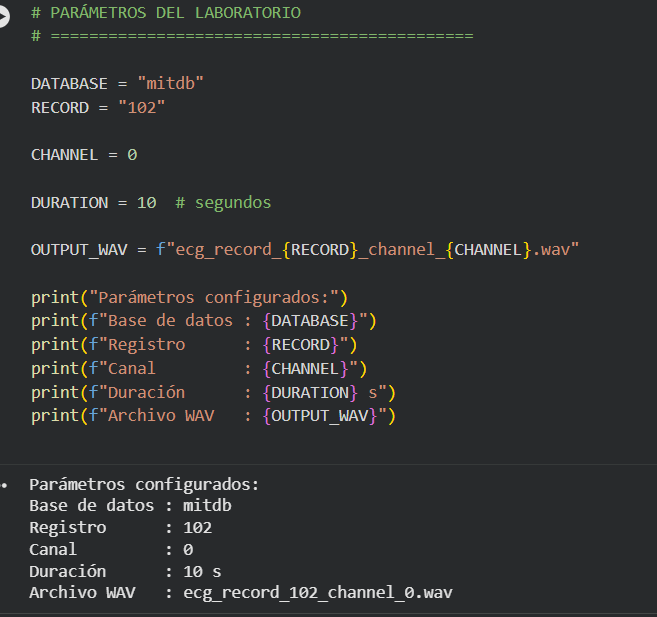

1. **Identificación de la base de datos.**

La base de datos utilizada fue mitdb, que corresponde a MIT-BIH Arrhythmia Database. Esta base de datos se encuentra disponible en PhysioNet y contiene registros reales de señales ECG.

2. **Identificación del registro.**

Para este análisis seleccioné el registro 102, el cual es diferente a los registros 100 y 101 que utilicé anteriormente.

3. **Frecuencia de muestreo.**

La frecuencia de muestreo del registro es: fs = 360Hz

Esto significa que se tomaron 360 muestras de la señal por cada segundo.


4. **Canal seleccionado.**

Se seleccionó el canal 0, llamado V5, cuyas amplitudes se encuentran expresadas en milivoltios (mV).

5. **Duración analizada.**

Se analizaron los primeros 10 segundos del registro. Como la frecuencia de muestreo es de 360 Hz, la cantidad de muestras analizadas fue:

N= fs * t

N= 360 * 10 = 3600 muestras


6. **Las 4 gráficas.**

i) Gráfica 1: ECG completo

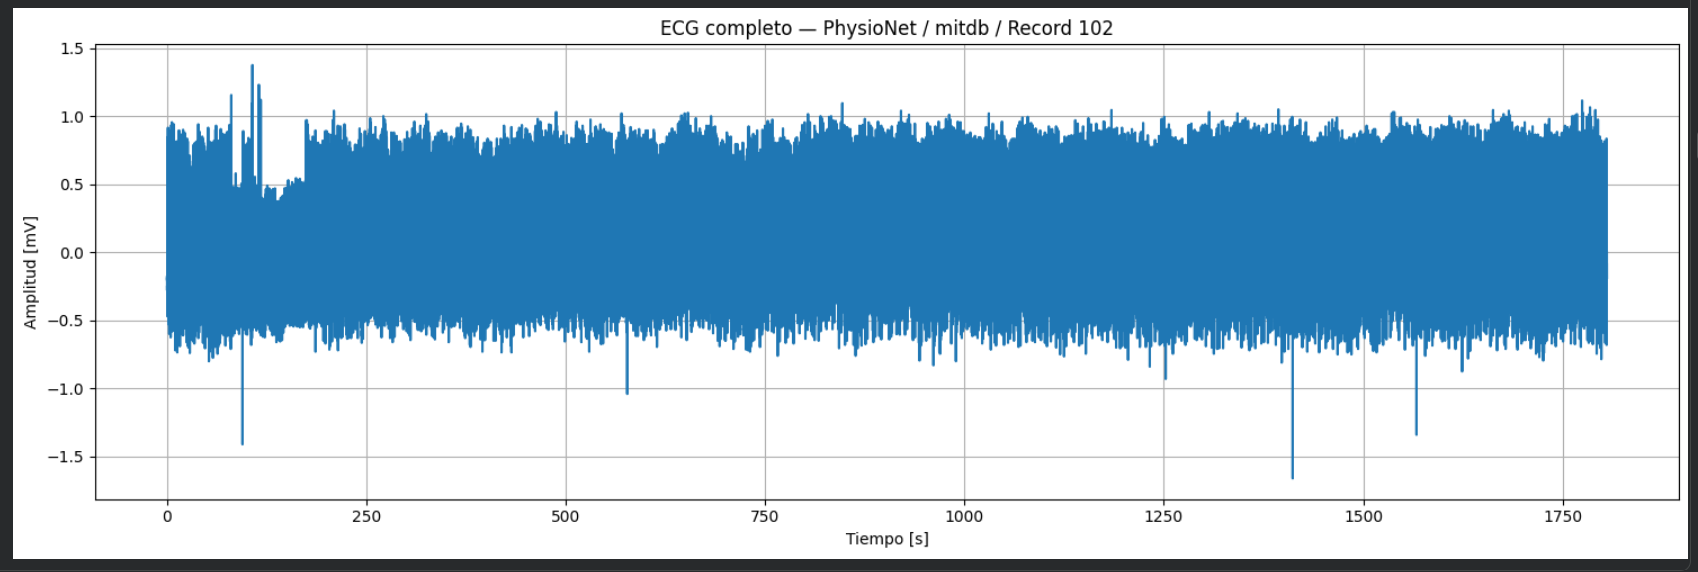

ii) Gráfica 2: Segmento de los primeros 10 segundos

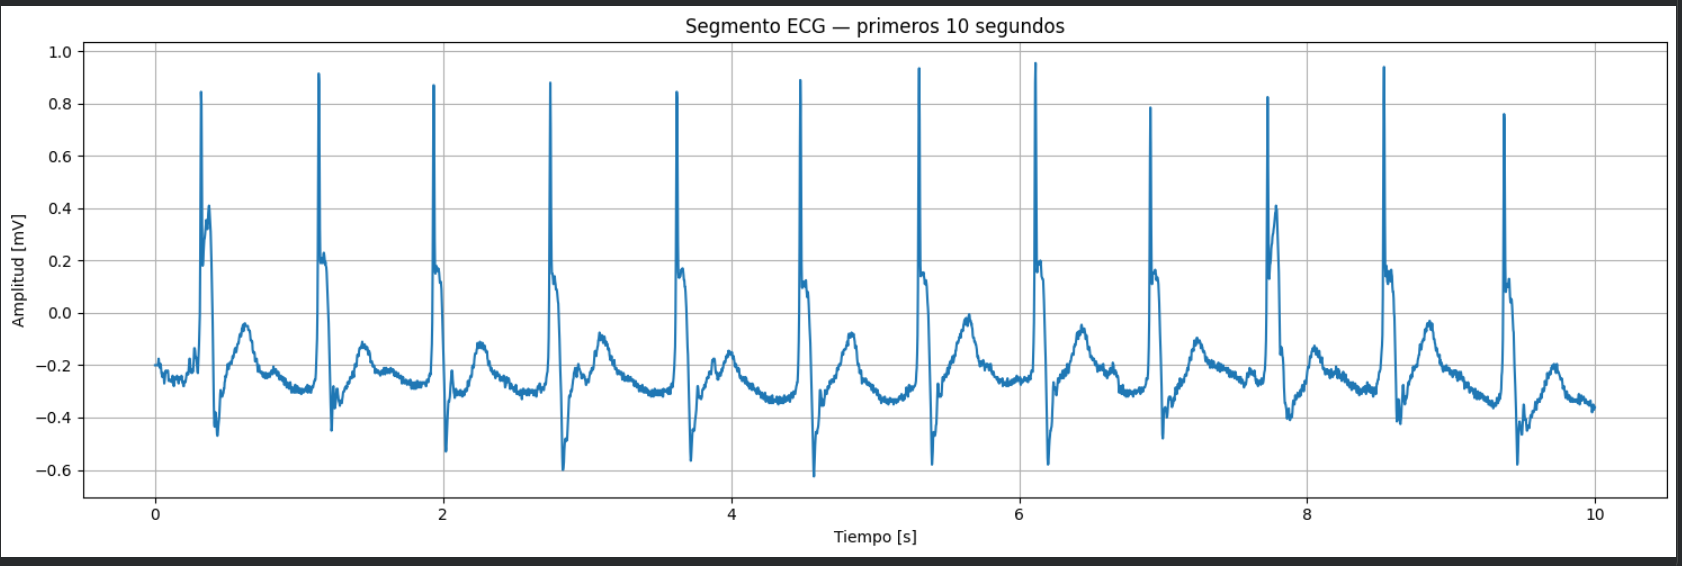

iii) Gráfica 3: Histograma de amplitudes

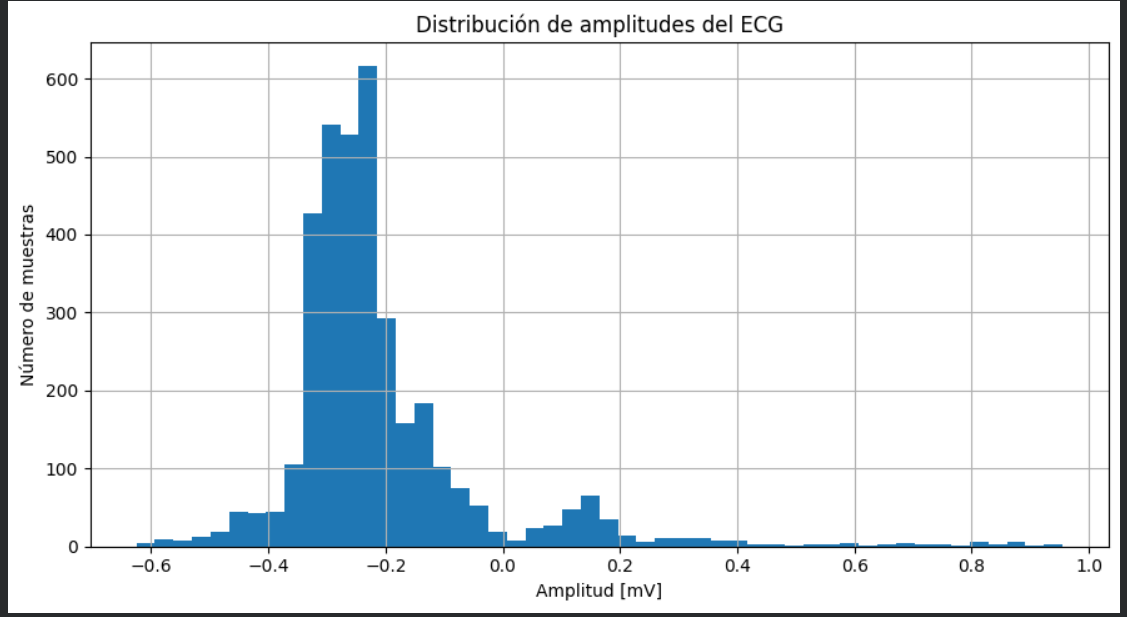

iv) Gráfica 4: Representación discreta

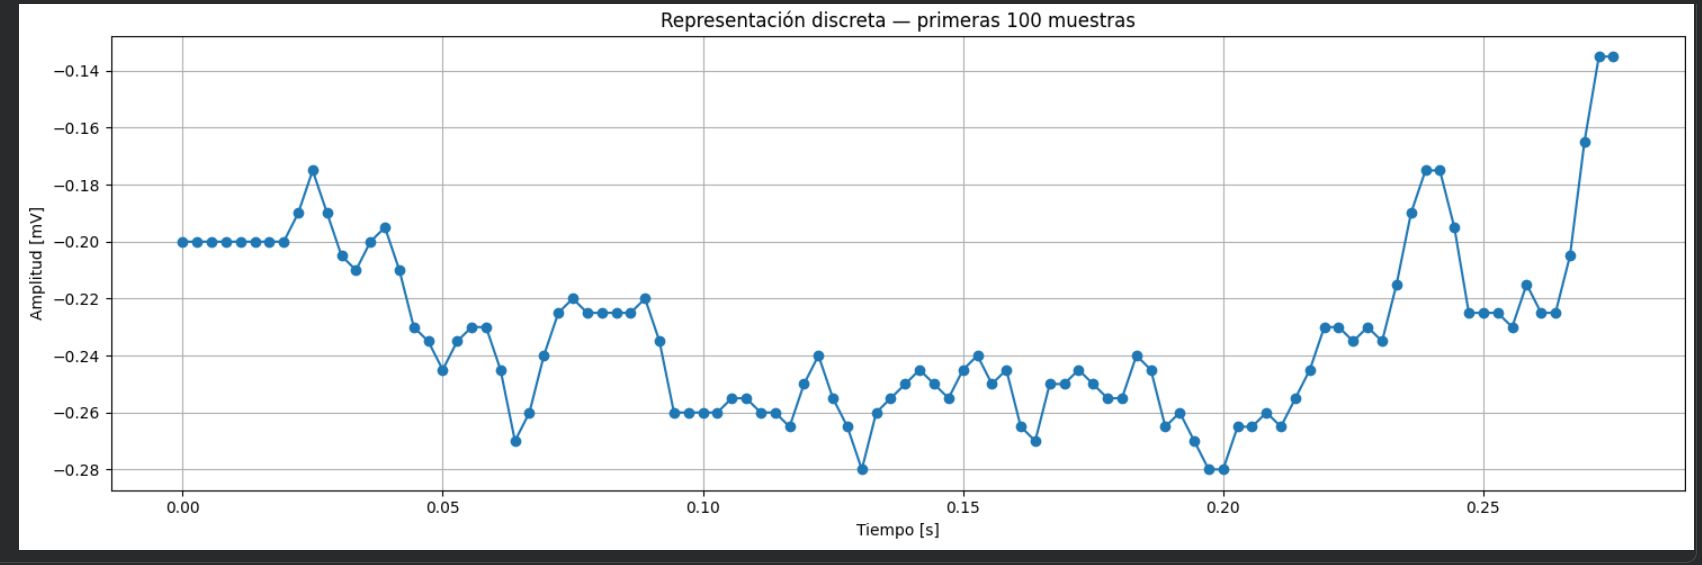

7. **Estadísticas.**

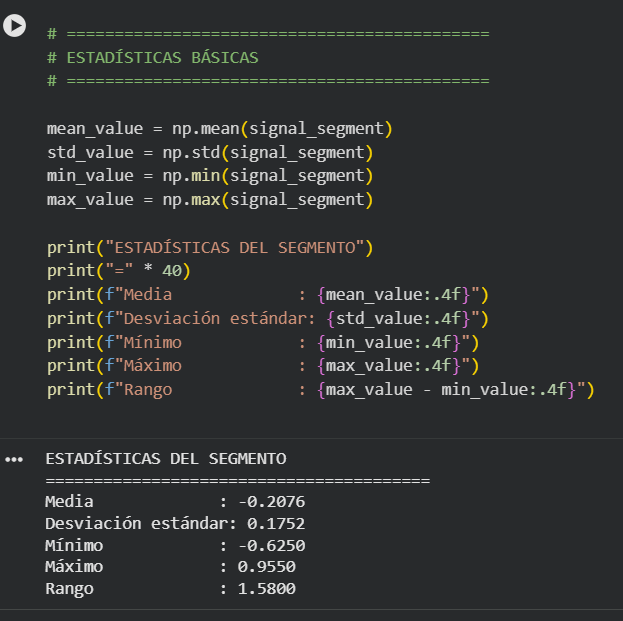

Para los primeros 10 segundos del registro 102 se obtuvieron los siguientes resultados:

- Media: -0.2076 mV
- Desviación estándar: 0.1752 mV
- Mínimo: -0.6250 mV
- Máximo: 0.9550 mV
- Rango: 1.5800 mV

La media indica que las amplitudes se encuentran principalmente alrededor de -0.21 mV. La desviación estándar indica cuánto se separan los valores de esta media. Por otro lado, la amplitud más baja fue -0.625 mV y la más alta fue 0.955 mV.

El rango se obtuvo restando el valor mínimo al máximo: Rango= 0.9550-(-0.6250)=1.5800

8. **Archivo WAV.**

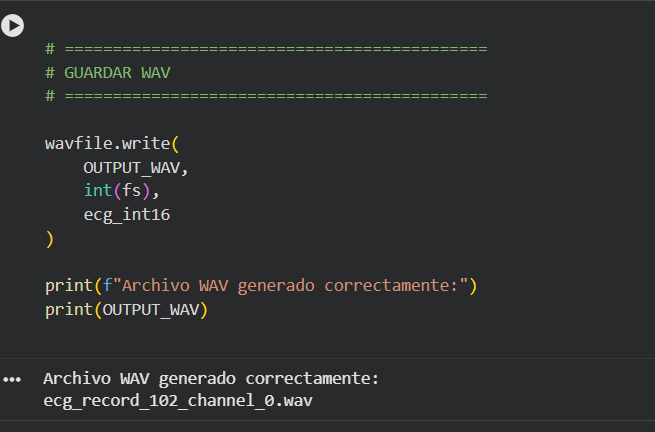

El archivo permite escuchar una representación de la señal analizada. Sin embargo, el audio obtenido no corresponde al sonido real del corazón, sino a la conversión de las amplitudes del ECG en valores que pueden reproducirse como audio.

9. **Interpretación de los resultados.**

En la gráfica del ECG completo se observa que la mayor parte de la señal se encuentra aproximadamente entre -0.8 y 1.1 mV. También se presentan algunas caídas más pronunciadas, por ejemplo, cerca de los 100, 1400 y 1570 segundos, llegando en algunos casos aproximadamente hasta -1.65 mV. Estas caídas podrían deberse a variaciones propias del registro o a posibles artefactos.

En la gráfica de los primeros 10 segundos se pueden reconocer aproximadamente 12 picos principales, los cuales corresponden a los complejos QRS. La mayoría de estos picos positivos alcanza valores aproximados entre 0.8 y 0.95 mV, mientras que las caídas posteriores llegan aproximadamente hasta -0.6 mV.

En el histograma se observa que la mayor cantidad de muestras se concentra aproximadamente entre -0.35 y -0.15 mV, con una mayor concentración cerca de -0.25 mV. También aparecen algunos valores positivos que llegan hasta aproximadamente 0.95 mV, pero son menos frecuentes y corresponden principalmente a los picos de la señal.

La representación discreta muestra las primeras 100 muestras, equivalentes aproximadamente a los primeros 0.275 segundos. En esta gráfica se puede observar cada muestra por separado y cómo la amplitud va cambiando entre aproximadamente -0.28 y -0.135 mV durante ese pequeño intervalo.

10. **Conclusiones.**

En este reto pude analizar el registro 102 de PhysioNet, utilizando el canal V5 y los primeros 10 segundos de la señal. Al trabajar con este segmento fue posible distinguir mejor los complejos QRS y observar cómo variaba su amplitud durante el tiempo.

El histograma permitió conocer dónde se concentraba la mayoría de los valores, mientras que la representación discreta permitió observar las muestras individualmente. También se calcularon las estadísticas principales de la señal y se logró exportar el segmento como un archivo WAV.

Finalmente, trabajar con una señal real permitió observar que el ECG no mantiene exactamente la misma forma ni amplitud durante todo el registro, ya que presenta pequeñas variaciones y algunos cambios bruscos.



# 21. Conclusiones esperadas

Al finalizar el laboratorio, el estudiante debería comprender que una señal biomédica puede estudiarse desde diferentes perspectivas:

```text
              SEÑAL ECG
                  │
       ┌──────────┼──────────┐
       ↓          ↓          ↓
     Tiempo    Amplitud   Distribución
       │          │          │
       └──────────┼──────────┘
                  ↓
          Señal discreta x[n]
                  ↓
          Procesamiento digital
                  ↓
        Filtros FIR / IIR
                  ↓
         Análisis de señales
```

Este laboratorio constituye la base para los siguientes laboratorios, donde se aplicarán técnicas de **procesamiento digital de señales**, incluyendo filtros FIR, filtros IIR, respuesta en frecuencia y Transformada Z.



# Referencias

- PhysioNet — plataforma de acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas Python para lectura y procesamiento de registros fisiológicos.
- MIT-BIH Arrhythmia Database — base de datos utilizada como ejemplo en este laboratorio.

**Nota:** consulte siempre la documentación oficial de la base de datos seleccionada para conocer el significado de sus registros, canales y anotaciones.
